In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.datasets import load_diabetes

In [2]:
Diabetes=load_diabetes()
X=pd.DataFrame(Diabetes.data, columns=Diabetes.feature_names)
y=pd.Series(Diabetes.target)

In [3]:
#Selecting all 10 columns
print(X.columns.tolist())
print(X.shape)

['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']
(442, 10)


In [4]:
#Train_test split
X_train, X_test, y_train, y_test=train_test_split(X, y, test_size=0.2, random_state=42)

In [5]:
#initializing and training the model
model=LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](10,)","[ 37.9 ,-241.96, 542.43,..., 275.32, 736.2 , 48.67]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](10,)","['age','sex','bmi',...,'s4','s5','s6']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,151.3
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,10
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(10)


In [6]:
print(f"Intercept:", model.intercept_)
print(f"Coefficients:", model.coef_)

Intercept: 151.34560453985995
Coefficients: [  37.90402135 -241.96436231  542.42875852  347.70384391 -931.48884588
  518.06227698  163.41998299  275.31790158  736.1988589    48.67065743]


In [7]:
#Making Predictions
y_pred=model.predict(X_test)

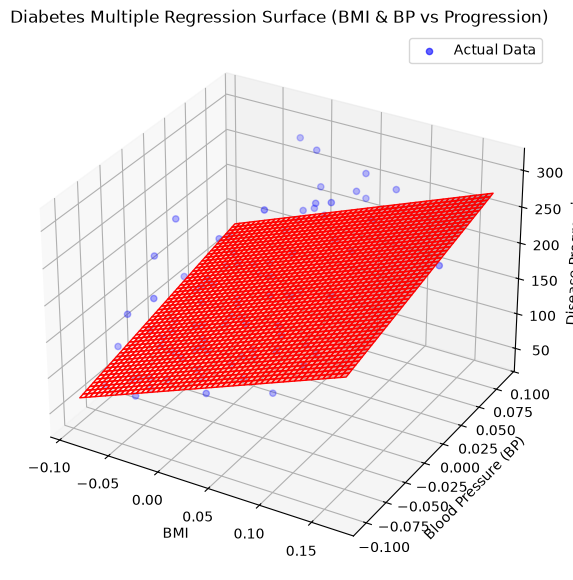

In [8]:
fig=plt.figure(figsize=(10, 7))
ax=fig.add_subplot(111, projection="3d")

ax.scatter(X_test["bmi"], X_test["bp"], y_test, color="blue", label="Actual Data", alpha=0.6)

#Creating a 2D grid for our two visual features
x1_range=np.linspace(X_test["bmi"].min(), X_test["bmi"].max(), 50)
x2_range=np.linspace(X_test["bp"].min(), X_test["bp"].max(), 50)
x1, x2=np.meshgrid(x1_range, x2_range)

dummy_grid=np.zeros((x1.size, 10))

bmi_idx=X_test.columns.get_loc("bmi")
bp_idx=X_test.columns.get_loc("bp")

dummy_grid[:, bmi_idx]=x1.ravel()
dummy_grid[:, bp_idx]=x2.ravel()

dummy_grid_df = pd.DataFrame(dummy_grid, columns=X_test.columns)

z=model.predict(dummy_grid_df).reshape(x1.shape)

ax.plot_surface(x1, x2, z, color="red", alpha=0.4, cmap="Reds")

ax.set_xlabel("BMI")
ax.set_ylabel("Blood Pressure (BP)")
ax.set_zlabel("Disease Progression")
ax.set_title("Diabetes Multiple Regression Surface (BMI & BP vs Progression)")
ax.legend()

plt.show()



#### Plot Observations & Data Context:
1. **From Line to Plane:** In our first model, our prediction was limited to a rigid 1D line. By expanding to Multiple Linear Regression, our model forms a 2D prediction **surface plane** slicing through a 3D feature space (`bmi` and `bp` vs `target`).
2. **Dual-Axis Impact:** The red surface explicitly slopes upward along both horizontal vectors. This captures the compounded risk of simultaneous high BMI and elevated Blood Pressure.
3. **Scaled Metrics Note:** The negative and decimal values on the BMI/BP axes are completely normal. Scikit-learn's built-in diabetes dataset is **pre-scaled and centered** (mean=0) to standardize feature variances prior to training.


In [9]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

multiple_mse=mean_squared_error(y_test, y_pred)
multiple_rmse=np.sqrt(multiple_mse)
multiple_r2=r2_score(y_test, y_pred)

print(f"Baseline (BMI only) ->R2 Score: 0.2334 | MSE: 4061.83 | RMSE: 63.73")
print(f"Multiple (10 features) -> R2 Score: {multiple_r2:.4f} | MSE: {multiple_mse:.2f} | RMSE: {multiple_rmse:.2f}")

Baseline (BMI only) ->R2 Score: 0.2334 | MSE: 4061.83 | RMSE: 63.73
Multiple (10 features) -> R2 Score: 0.4526 | MSE: 2900.19 | RMSE: 53.85


### Final Project Conclusion & Model Comparison

| Model Architecture | Features Used | $R^2$ Score (Variance Explained) | Mean Squared Error (MSE) | Root Mean Squared Error (RMSE) |
| :--- | :--- | :--- | :--- | :--- |
| **Simple Linear Regression** | `bmi` only | 23.34% | 4,061.83 | 63.73 units |
| **Multiple Linear Regression** | All 10 features | **45.26%** | **2,900.19** | **53.85 units** |

#### Key Insights & Key Takeaways
1. **Significant Error Reduction:** By including all 10 baseline medical features, our model's average prediction error (**RMSE**) dropped from **63.73 down to 53.85**. This indicates our multi-feature predictions are substantially closer to actual clinical outcomes.
2. **Doubled Explanatory Power:** The $R^2$ score increased from **0.2334 to 0.4526**. This mathematically proves that blood serum measurements, age, and blood pressure carry vital predictive signals that body mass index alone cannot capture.
3. **The Data Science Reality:** Even with all 10 features, an $R^2$ score of ~45% means that roughly 55% of the variance remains unexplained. In real-world healthcare modeling, human biology is highly complex, and linear boundaries have structural limits. Future iterations could explore regularization techniques (Ridge/Lasso) or non-linear algorithms to capture the remaining variance.
